# Heart Rate Variability Analysis in Congestive Heart Failure

**Dataset:** PhysioNet Congestive Heart Failure RR Interval Database  
**Number of Patients:** 29

---

## Project Overview

This notebook analyses RR interval data from severe heart failure patients to:
1. Compute time-domain HRV metrics (SDNN, RMSSD)
2. Clean artifacts from physiological signals
3. Identify distinct autonomic dysfunction phenotypes using unsupervised learning

**Research Question:** Can we identify distinct physiological phenotypes among CHF patients based on heart rate variability patterns?

---

## 1. Setup and Installation

### Install Required Packages

In [1]:
# Uncomment if running for the first time
# !pip install wfdb numpy pandas matplotlib seaborn scikit-learn

### Import Libraries

In [4]:
# Data handling
import numpy as np
import pandas as pd
import wfdb
import os
import re
import zipfile

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Display settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Loading and Extraction

### Extract PhysioNet Database

The CHF RR Interval Database contains:
- `.hea` files: Header files with patient metadata
- `.ecg` files: Annotation files marking R-peak locations
- `.dat` files: Raw ECG signal data (not used in this analysis)

In [6]:
# Extract data from zip file
zip_path = 'congestive-heart-failure-rr-interval-database-1.0.0.zip'

# Extract everything first
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('data')

# The files are inside a subfolder
# Check what's in the extracted folder
extracted_folder = 'data/congestive-heart-failure-rr-interval-database-1.0.0'

# Verify files are present
files = os.listdir(extracted_folder)
print(f"Total files extracted: {len(files)}")
print(f"\nSample files: {files[:10]}")

# Now copy or move files to data/chfdb for easier access
import shutil
os.makedirs('data/chfdb', exist_ok=True)

for file in files:
    if file.endswith(('.dat', '.hea', '.ecg')):
        shutil.copy(f'{extracted_folder}/{file}', f'data/chfdb/{file}')

Total files extracted: 62

Sample files: ['ANNOTATORS', 'chf201.ecg', 'chf201.hea', 'chf202.ecg', 'chf202.hea', 'chf203.ecg', 'chf203.hea', 'chf204.ecg', 'chf204.hea', 'chf205.ecg']


## 3. Patient Demographics

### Load Demographic Information

Extract age, sex, and NYHA classification from header files using regex patterns.


In [7]:
# Extract patient metadata from header files
patient_data = []

for i in range(201, 230):  # 29 CHF patients (chf201 to chf229)
    record_name = f'chf{i}'
    
    try:
        # Read header file
        record = wfdb.rdheader(f'data/chfdb/{record_name}')
        
        # Parse comment field containing demographics
        comment = record.comments[0] if record.comments else ''
        
        # Extract using regex patterns
        age = re.search(r'Age: (\d+)', comment)
        sex = re.search(r'Sex: (\w+)', comment)
        nyha = re.search(r'NYHA class: ([\w-]+)', comment)
        
        patient_data.append({
            'patient_id': record_name,
            'age': int(age.group(1)) if age else None,
            'sex': sex.group(1) if sex else None,
            'nyha_class': nyha.group(1) if nyha else None
        })
        print(f"{record_name}")
        
    except FileNotFoundError:
        print(f"{record_name}: File not found")
    except Exception as e:
        print(f"{record_name}: {str(e)[:50]}...")  # Truncate long error messages

# Create DataFrame
df_patients = pd.DataFrame(patient_data)
print("\n" + "="*60)
print("Patient Demographics:")
print(df_patients)

if len(df_patients) > 0:
    print(f"\nAge range: {df_patients['age'].min():.0f} - {df_patients['age'].max():.0f} years")
    print(f"Sex distribution: {df_patients['sex'].value_counts().to_dict()}")
    print(f"\nSuccessfully loaded: {len(df_patients)} patients")
else:
    print(" No patients loaded successfully")

chf201
chf202
chf203
chf204
chf205
chf206
chf207
chf208
chf209
chf210
chf211
chf212
chf213
chf214
chf215
chf216
chf217
chf218
chf219
chf220
chf221
chf222
chf223
chf224
chf225
chf226
chf227
chf228
chf229

Patient Demographics:
   patient_id  age   sex nyha_class
0      chf201   55     M        III
1      chf202   59     F        III
2      chf203   68     M        III
3      chf204   62     M        III
4      chf205   39     M        III
5      chf206   38     F        III
6      chf207   62     M        III
7      chf208   62     M        III
8      chf209   65     M        III
9      chf210   43     M        III
10     chf211   34  None         II
11     chf212   54  None         II
12     chf213   53  None          I
13     chf214   79  None         II
14     chf215   43  None         II
15     chf216   58  None         II
16     chf217   50  None          I
17     chf218   72  None          I
18     chf219   62  None        III
19     chf220   64  None         II
20     chf221   37

## 4. RR Interval Extraction and Visualization

### Load Sample Patient Data

RR intervals represent the time between consecutive heartbeats (R-peak to R-peak).

Sampling frequency: 128 Hz
Number of heartbeats: 112,233
Number of RR intervals: 112,232

First 10 RR intervals (ms): [757 789 765 734 757 765 765 726 726 742]
Mean RR interval: 738.0 ms
Mean heart rate: 81.3 bpm


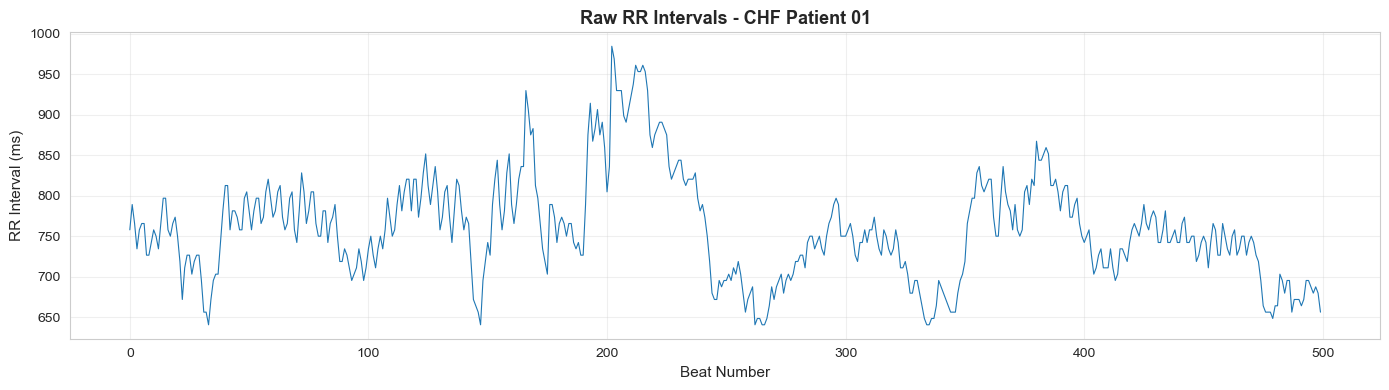

In [8]:
# Load RR intervals for one patient as an example
ann_chf01 = wfdb.rdann('data/chfdb/chf201', 'ecg')  # Annotation file with R-peak locations
rr_intervals_samples = np.diff(ann_chf01.sample)  # Calculate intervals between consecutive peaks

# Get sampling frequency from header
record = wfdb.rdheader('data/chfdb/chf201')
fs = record.fs  # Sampling frequency in Hz (should be 250 Hz)

# Convert from samples to milliseconds
# Formula: (samples / sampling_rate) * 1000 = milliseconds
rr_intervals_ms = (rr_intervals_samples / fs) * 1000

print(f"Sampling frequency: {fs} Hz")
print(f"Number of heartbeats: {len(ann_chf01.sample):,}")
print(f"Number of RR intervals: {len(rr_intervals_ms):,}")
print(f"\nFirst 10 RR intervals (ms): {rr_intervals_ms[:10].astype(int)}")
print(f"Mean RR interval: {np.mean(rr_intervals_ms):.1f} ms")
print(f"Mean heart rate: {60000/np.mean(rr_intervals_ms):.1f} bpm")

# Visualize raw RR intervals
plt.figure(figsize=(14, 4))
plt.plot(rr_intervals_ms[:500], linewidth=0.8)  # First 500 intervals
plt.xlabel('Beat Number', fontsize=11)
plt.ylabel('RR Interval (ms)', fontsize=11)
plt.title('Raw RR Intervals - CHF Patient 01', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Data Cleaning and Artifact Removal

### Two-Step Cleaning Process

**Step 1: Range Filtering**
Remove physiologically impossible values:
- RR < 300 ms → Heart rate > 200 bpm (unsustainable)
- RR > 2000 ms → Heart rate < 30 bpm (life-threatening)

**Step 2: Artifact Detection**
Remove sudden jumps using a 20% threshold:
- Beat-to-beat changes >20% are likely detection errors
- Compares each interval to the last accepted interval

Original intervals: 112,232
After range filtering: 112,186
After artifact removal: 90,634
Total removed: 21,598 (19.24%)


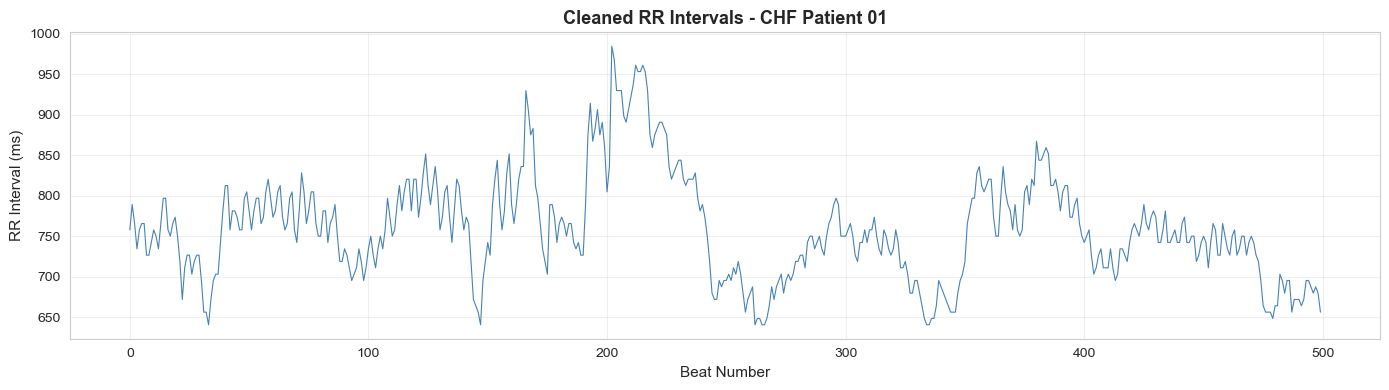

In [9]:
def clean_rr_intervals(rr_ms, max_percent_change=0.2):
    """
    Remove artifacts from RR interval data.
    
    Parameters:
    -----------
    rr_ms : array
        RR intervals in milliseconds
    max_percent_change : float
        Maximum allowed percent change between consecutive intervals (default: 0.2 = 20%)
    
    Returns:
    --------
    array : Cleaned RR intervals
    """
    rr_clean = [rr_ms[0]]  # Keep first value as baseline
    
    for i in range(1, len(rr_ms)):
        prev_rr = rr_clean[-1]
        current_rr = rr_ms[i]
        
        # Calculate percent change from previous interval
        percent_change = abs(current_rr - prev_rr) / prev_rr
        
        # Only keep if change is reasonable
        if percent_change < max_percent_change:
            rr_clean.append(current_rr)
    
    return np.array(rr_clean)


# Apply cleaning to patient chf01
# Step 1: Remove physiologically implausible values
rr_filtered = rr_intervals_ms[(rr_intervals_ms > 300) & (rr_intervals_ms < 2000)]

# Step 2: Remove sudden jumps (artifacts)
rr_clean = clean_rr_intervals(rr_filtered)

print(f"Original intervals: {len(rr_intervals_ms):,}")
print(f"After range filtering: {len(rr_filtered):,}")
print(f"After artifact removal: {len(rr_clean):,}")
print(f"Total removed: {len(rr_intervals_ms) - len(rr_clean):,} ({100*(len(rr_intervals_ms) - len(rr_clean))/len(rr_intervals_ms):.2f}%)")

# Visualize cleaned data
plt.figure(figsize=(14, 4))
plt.plot(rr_clean[:500], linewidth=0.8, color='steelblue')
plt.xlabel('Beat Number', fontsize=11)
plt.ylabel('RR Interval (ms)', fontsize=11)
plt.title('Cleaned RR Intervals - CHF Patient 01', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Heart Rate Variability Metrics

### Time-Domain HRV Analysis

**SDNN (Standard Deviation of NN Intervals):**
- Measures overall HRV
- Reflects both sympathetic and parasympathetic activity
- **Normal:** >100 ms
- **CHF patients typically:** <50 ms

**RMSSD (Root Mean Square of Successive Differences):**
- Measures beat-to-beat variability
- Specifically reflects parasympathetic (vagal) activity
- **Normal:** >40 ms
- **CHF patients typically:** <20 ms

In [12]:
def calculate_hrv_metrics(rr_intervals):
    """
    Calculate time-domain HRV metrics.
    
    Parameters:
    -----------
    rr_intervals : array
        Cleaned RR intervals in milliseconds
    
    Returns:
    --------
    dict : Dictionary containing HRV metrics
    """
    # SDNN: Standard deviation of all NN intervals
    sdnn = np.std(rr_intervals, ddof=1)  # ddof=1 for sample std
    
    # RMSSD: Root mean square of successive differences
    successive_diffs = np.diff(rr_intervals)  # Calculate differences between consecutive intervals
    rmssd = np.sqrt(np.mean(successive_diffs**2))  # Square, average, then square root
    
    # Basic statistics
    mean_rr = np.mean(rr_intervals)
    mean_hr = 60000 / mean_rr  # Convert RR interval to heart rate (bpm)
    
    return {
        'mean_rr_ms': mean_rr,
        'mean_hr_bpm': mean_hr,
        'sdnn_ms': sdnn,
        'rmssd_ms': rmssd
    }


# Calculate HRV for patient chf01
hrv_chf201 = calculate_hrv_metrics(rr_clean)

print("="*50)
print("HRV Metrics for CHF Patient 201:")
print("="*50)
print(f"Mean RR interval: {hrv_chf01['mean_rr_ms']:.1f} ms")
print(f"Mean heart rate:  {hrv_chf01['mean_hr_bpm']:.1f} bpm")
print(f"SDNN:             {hrv_chf01['sdnn_ms']:.1f} ms  (Normal: >100 ms)")
print(f"RMSSD:            {hrv_chf01['rmssd_ms']:.1f} ms  (Normal: >40 ms)")
print("="*50)

# Clinical interpretation
if hrv_chf201['sdnn_ms'] < 50:
    print("\n  SDNN indicates severely reduced HRV")
elif hrv_chf201['sdnn_ms'] < 100:
    print("\n  SDNN indicates moderately reduced HRV")
else:
    print("\n✓ SDNN within normal range")
    
if hrv_chf201['rmssd_ms'] < 20:
    print("  RMSSD indicates severely impaired parasympathetic function")
elif hrv_chf201['rmssd_ms'] < 40:
    print("  RMSSD indicates moderately impaired parasympathetic function")
else:
    print("✓ RMSSD within normal range")

HRV Metrics for CHF Patient 201:
Mean RR interval: 741.1 ms
Mean heart rate:  81.0 bpm
SDNN:             75.5 ms  (Normal: >100 ms)
RMSSD:            19.6 ms  (Normal: >40 ms)

  SDNN indicates severely reduced HRV
  RMSSD indicates severely impaired parasympathetic function


## 7. Analysis Across All Patients

### Compute HRV for Entire Cohort


In [13]:
# Calculate HRV metrics for all CHF patients
all_patients_hrv = []

for i in range(201, 230):  # chf201 to chf229
    record_name = f'chf{i}'
    
    try:
        # Load RR intervals
        ann = wfdb.rdann(f'data/chfdb/{record_name}', 'ecg')
        rr_intervals = np.diff(ann.sample)
        
        # Convert to milliseconds
        rr_ms = (rr_intervals / 250) * 1000
        
        # Clean data
        rr_ms = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]  # Remove implausible values
        rr_clean = clean_rr_intervals(rr_ms)  # Remove artifacts
        
        # Calculate HRV metrics
        hrv = calculate_hrv_metrics(rr_clean)
        hrv['patient_id'] = record_name
        all_patients_hrv.append(hrv)
        
        print(f" {record_name}")
        
    except Exception as e:
        print(f" {record_name}: {e}")

# Create DataFrame for analysis
df_hrv = pd.DataFrame(all_patients_hrv)

# Reorder columns for better readability
df_hrv = df_hrv[['patient_id', 'mean_hr_bpm', 'mean_rr_ms', 'sdnn_ms', 'rmssd_ms']]

print("\n" + "="*70)
print("HRV Metrics Summary - All Patients")
print("="*70)
print(df_hrv.to_string(index=False))
print("\n" + "="*70)
print("\nDescriptive Statistics:")
print(df_hrv[['mean_hr_bpm', 'sdnn_ms', 'rmssd_ms']].describe().round(2))

 chf201
 chf202
 chf203
 chf204
 chf205
 chf206
 chf207
 chf208
 chf209
 chf210
 chf211
 chf212
 chf213
 chf214
 chf215
 chf216
 chf217
 chf218
 chf219
 chf220
 chf221
 chf222
 chf223
 chf224
 chf225
 chf226
 chf227
 chf228
 chf229

HRV Metrics Summary - All Patients
patient_id  mean_hr_bpm  mean_rr_ms   sdnn_ms  rmssd_ms
    chf201   158.205741  379.252989 37.095759 10.049734
    chf202   169.169610  354.673633 35.438526 14.037655
    chf203   155.709057  385.334040 19.656413  7.354770
    chf204   155.763248  385.199979 26.618541 12.034901
    chf205   191.451025  313.396077 11.949053  7.592643
    chf206   194.026888  309.235491  9.652189  9.925040
    chf207   180.589596  332.245053 25.657928 20.289771
    chf208   149.382127  401.654477 22.739817 16.576571
    chf209   188.501435  318.299963  9.051417  5.380773
    chf210   193.824165  309.558923  7.649211  6.003082
    chf211   165.598214  362.322749 41.566538 15.900496
    chf212   189.066029  317.349448 16.811996 15.055061
    

## 8. Data Visualization

### Comparative HRV Analysis

Four-panel visualization showing:
1. **SDNN distribution** - Overall variability across patients
2. **RMSSD distribution** - Parasympathetic function across patients
3. **Heart rate distribution** - Baseline cardiac rhythm
4. **SDNN vs RMSSD relationship** - Correlation between HRV metrics

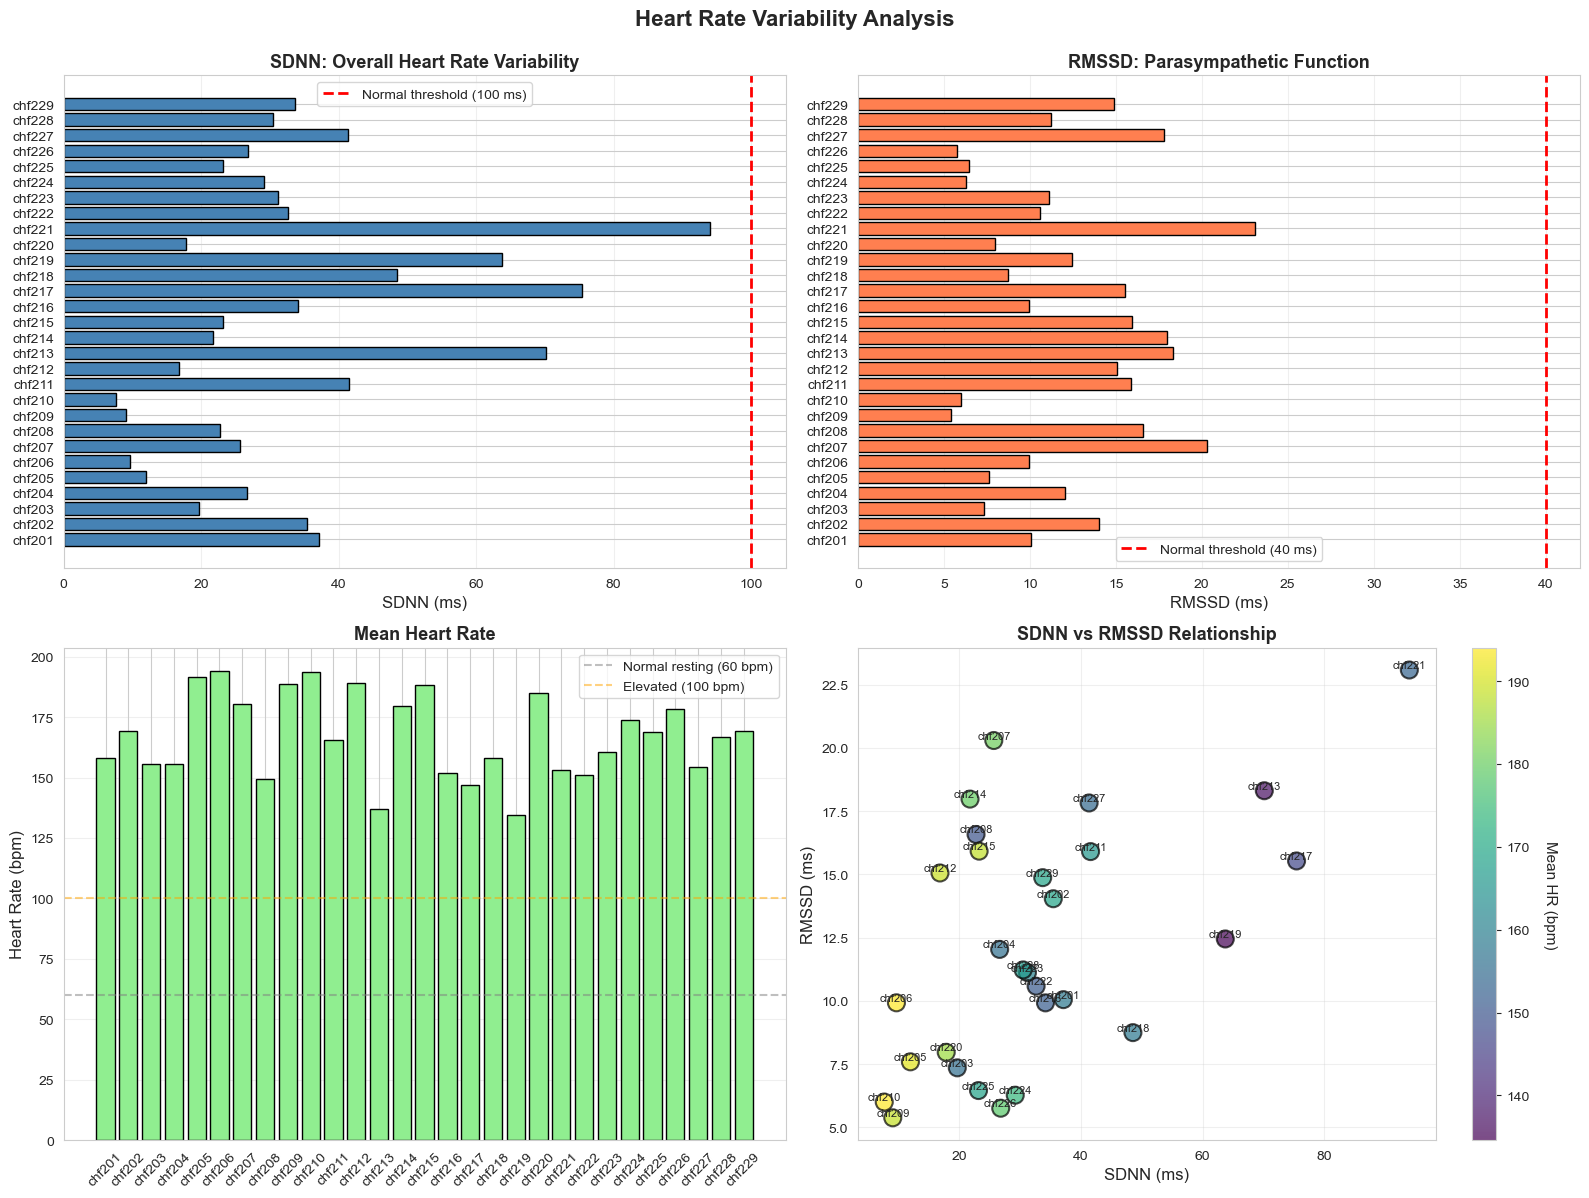

In [15]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heart Rate Variability Analysis', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. SDNN distribution
axes[0, 0].barh(df_hrv['patient_id'], df_hrv['sdnn_ms'], color='steelblue', edgecolor='black')
axes[0, 0].axvline(x=100, color='red', linestyle='--', linewidth=2, label='Normal threshold (100 ms)')
axes[0, 0].set_xlabel('SDNN (ms)', fontsize=12)
axes[0, 0].set_title('SDNN: Overall Heart Rate Variability', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. RMSSD distribution
axes[0, 1].barh(df_hrv['patient_id'], df_hrv['rmssd_ms'], color='coral', edgecolor='black')
axes[0, 1].axvline(x=40, color='red', linestyle='--', linewidth=2, label='Normal threshold (40 ms)')
axes[0, 1].set_xlabel('RMSSD (ms)', fontsize=12)
axes[0, 1].set_title('RMSSD: Parasympathetic Function', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Heart rate distribution
axes[1, 0].bar(df_hrv['patient_id'], df_hrv['mean_hr_bpm'], color='lightgreen', edgecolor='black')
axes[1, 0].axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='Normal resting (60 bpm)')
axes[1, 0].axhline(y=100, color='orange', linestyle='--', alpha=0.5, label='Elevated (100 bpm)')
axes[1, 0].set_ylabel('Heart Rate (bpm)', fontsize=12)
axes[1, 0].set_title('Mean Heart Rate', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. SDNN vs RMSSD scatter plot
scatter = axes[1, 1].scatter(df_hrv['sdnn_ms'], df_hrv['rmssd_ms'], 
                            s=150, alpha=0.7, c=df_hrv['mean_hr_bpm'], 
                            cmap='viridis', edgecolors='black', linewidth=1.5)
axes[1, 1].set_xlabel('SDNN (ms)', fontsize=12)
axes[1, 1].set_ylabel('RMSSD (ms)', fontsize=12)
axes[1, 1].set_title('SDNN vs RMSSD Relationship', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('Mean HR (bpm)', rotation=270, labelpad=20, fontsize=11)

# Add patient labels to scatter plot
for idx, row in df_hrv.iterrows():
    axes[1, 1].annotate(row['patient_id'], 
                       (row['sdnn_ms'], row['rmssd_ms']),
                       fontsize=8, ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Interpretation:**
- Red reference lines show normal thresholds
- All patients fall below normal ranges
- Wide variation despite uniform diagnosis
- Color coding by heart rate reveals potential phenotypes


## 9. Poincaré Plot Analysis

### Beat-to-Beat Dynamics Visualization

Poincaré plots show RR(n) vs RR(n+1) - each point represents consecutive heartbeats.

**What the shape tells us:**
- **Tight cluster** → Low variability → Severe autonomic dysfunction
- **Wide cloud** → High variability → Better autonomic function
- **Distance from identity line** → Magnitude of beat-to-beat changes

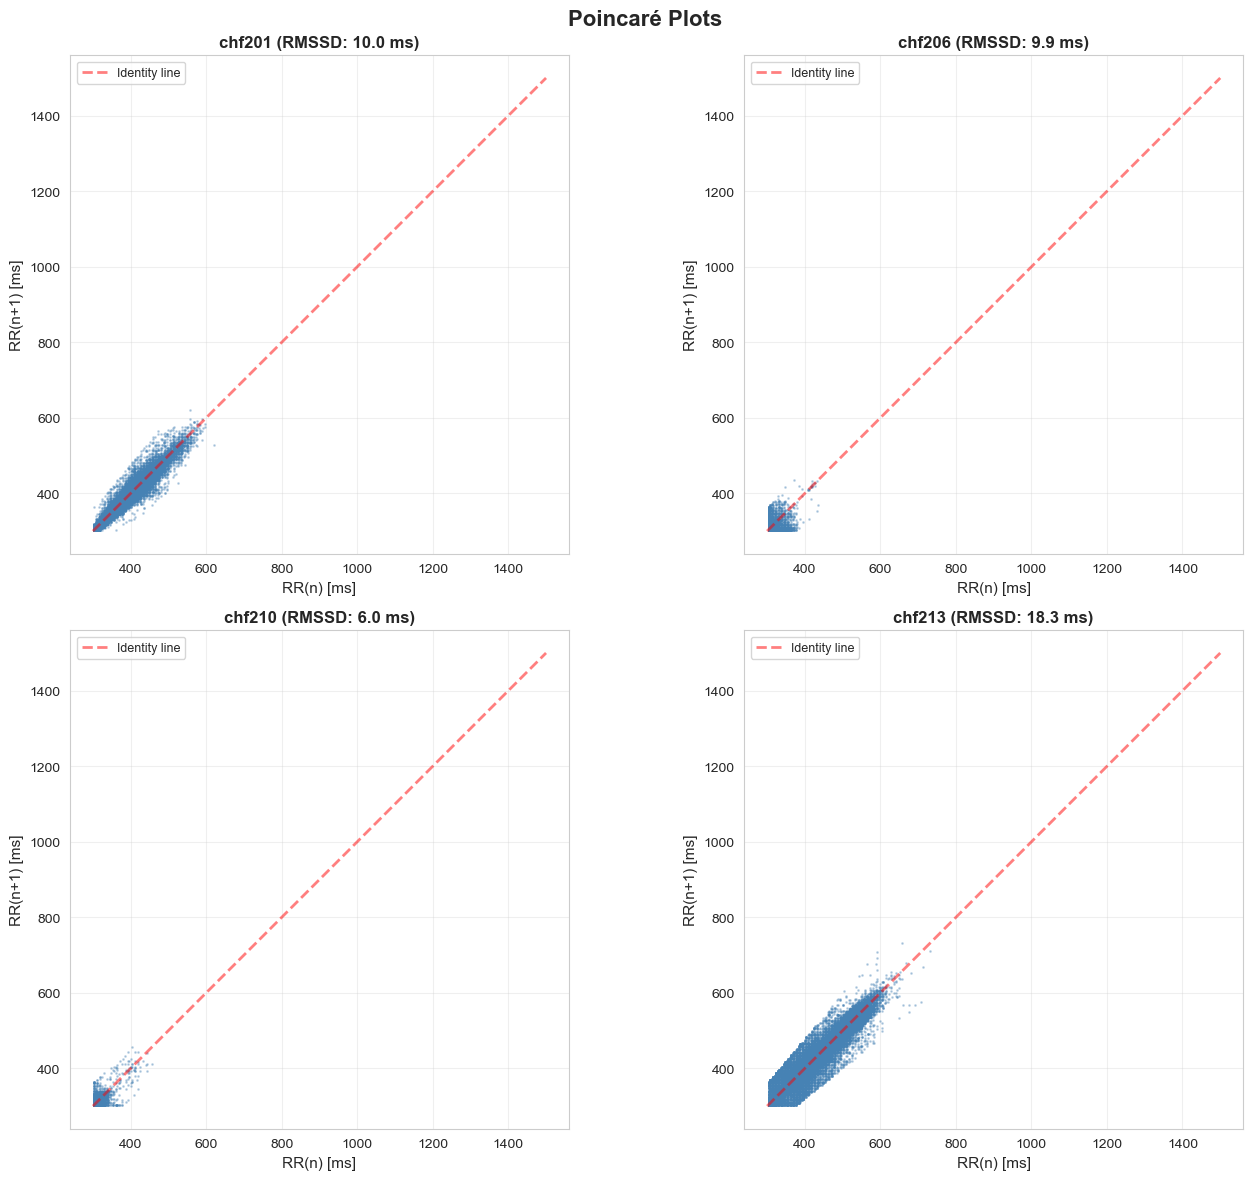

In [17]:
# Create Poincaré plots for representative patients
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Poincaré Plots', 
             fontsize=16, fontweight='bold')

# Select patients with different HRV profiles
patients_to_plot = ['chf201', 'chf206', 'chf210', 'chf213']

# Get RMSSD values for titles
rmssd_values = {}
for p in patients_to_plot:
    rmssd_values[p] = df_hrv[df_hrv['patient_id'] == p]['rmssd_ms'].values[0]

patient_names = [
    f'chf201 (RMSSD: {rmssd_values["chf201"]:.1f} ms)',
    f'chf206 (RMSSD: {rmssd_values["chf206"]:.1f} ms)',
    f'chf210 (RMSSD: {rmssd_values["chf210"]:.1f} ms)',
    f'chf213 (RMSSD: {rmssd_values["chf213"]:.1f} ms)'
]

for idx, (patient, name) in enumerate(zip(patients_to_plot, patient_names)):
    ax = axes[idx // 2, idx % 2]
    
    # Load and clean data
    ann = wfdb.rdann(f'data/chfdb/{patient}', 'ecg')
    rr_intervals = np.diff(ann.sample)
    rr_ms = (rr_intervals / 250) * 1000
    rr_ms = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    rr_clean = clean_rr_intervals(rr_ms)
    
    # Create Poincaré plot: RR(n) vs RR(n+1)
    rr_n = rr_clean[:-1]
    rr_n1 = rr_clean[1:]
    
    ax.scatter(rr_n, rr_n1, alpha=0.3, s=1, color='steelblue')
    ax.plot([300, 1500], [300, 1500], 'r--', alpha=0.5, linewidth=2, label='Identity line')
    ax.set_xlabel('RR(n) [ms]', fontsize=11)
    ax.set_ylabel('RR(n+1) [ms]', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. Unsupervised Phenotype Discovery

### t-SNE Dimensionality Reduction

**Methodology:**
- Features: mean_rr_ms, sdnn_ms, rmssd_ms, mean_hr_bpm
- Standardisation: StandardScaler (zero mean, unit variance)
- Algorithm: t-SNE with perplexity=5 (appropriate for n=29)
- Output: 2D embedding preserving local structure

**Why perplexity=5?**
For small datasets (n<50), perplexity should be roughly 1/5 to 1/3 of sample size. With 29 patients, perplexity=5 focuses on immediate neighbours while avoiding overfitting.

In [18]:
# Prepare features for dimensionality reduction
features = df_hrv[['mean_rr_ms', 'sdnn_ms', 'rmssd_ms', 'mean_hr_bpm']].values
patient_ids = df_hrv['patient_id'].values

# Standardize features (important for t-SNE)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Feature matrix shape:", features_scaled.shape)
print("Features used: mean_rr_ms, sdnn_ms, rmssd_ms, mean_hr_bpm")
print("\nApplying t-SNE...")

# Apply t-SNE
# perplexity=5 is appropriate for small dataset (15 patients)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_results = tsne.fit_transform(features_scaled)

print(" t-SNE complete!")
print(f"2D embedding shape: {tsne_results.shape}")

Feature matrix shape: (29, 4)
Features used: mean_rr_ms, sdnn_ms, rmssd_ms, mean_hr_bpm

Applying t-SNE...
 t-SNE complete!
2D embedding shape: (29, 2)


### Visualization Strategy

Two complementary views:
1. **Colored by RMSSD** - Shows parasympathetic function gradient
2. **Colored by Heart Rate** - Shows tachycardia patterns

**Expected Clustering:**
- Patients with similar autonomic profiles cluster together
- Color gradients reveal phenotype characteristics
- Spatial separation indicates distinct dysfunction patterns


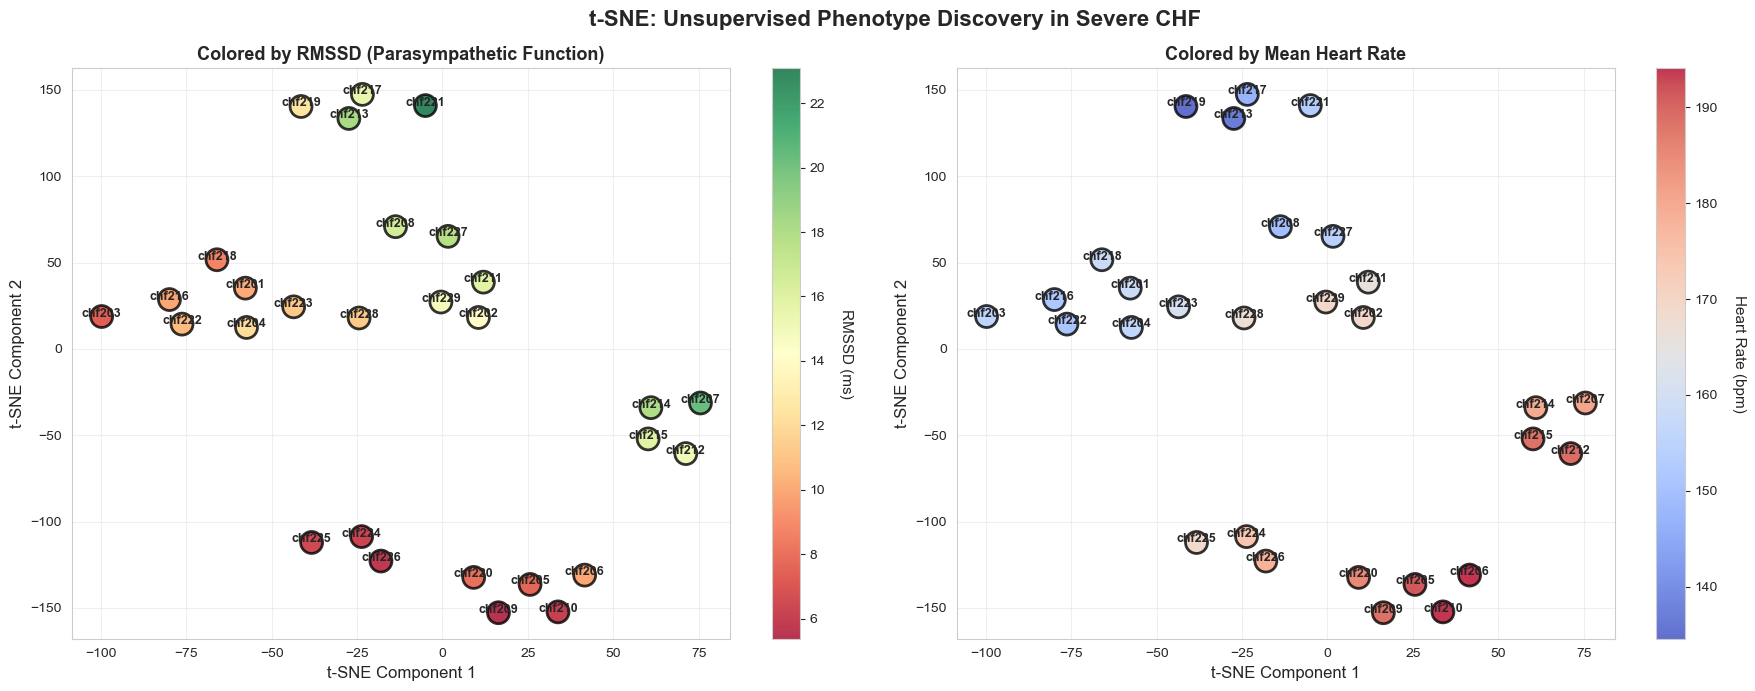

In [19]:
# Create t-SNE visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE: Unsupervised Phenotype Discovery in Severe CHF', 
             fontsize=16, fontweight='bold')

# Plot 1: Colored by RMSSD (parasympathetic function)
scatter1 = axes[0].scatter(tsne_results[:, 0], tsne_results[:, 1], 
                          c=df_hrv['rmssd_ms'], s=250, cmap='RdYlGn', 
                          edgecolors='black', linewidth=2, alpha=0.8)
axes[0].set_title('Colored by RMSSD (Parasympathetic Function)', 
                 fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE Component 1', fontsize=12)
axes[0].set_ylabel('t-SNE Component 2', fontsize=12)
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('RMSSD (ms)', rotation=270, labelpad=20, fontsize=11)

# Add patient labels
for i, patient in enumerate(patient_ids):
    axes[0].annotate(patient, (tsne_results[i, 0], tsne_results[i, 1]), 
                    fontsize=9, ha='center', fontweight='bold')

# Plot 2: Colored by heart rate
scatter2 = axes[1].scatter(tsne_results[:, 0], tsne_results[:, 1], 
                          c=df_hrv['mean_hr_bpm'], s=250, cmap='coolwarm', 
                          edgecolors='black', linewidth=2, alpha=0.8)
axes[1].set_title('Colored by Mean Heart Rate', 
                 fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE Component 1', fontsize=12)
axes[1].set_ylabel('t-SNE Component 2', fontsize=12)
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Heart Rate (bpm)', rotation=270, labelpad=20, fontsize=11)

# Add patient labels
for i, patient in enumerate(patient_ids):
    axes[1].annotate(patient, (tsne_results[i, 0], tsne_results[i, 1]), 
                    fontsize=9, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Key Findings

### Clinical Insights

**Universal Autonomic Dysfunction:**
- Mean heart rate:167 bpm (normal resting: 60-100 bpm)
- All patients show tachycardia and severely reduced HRV
- Confirms autonomic failure as a hallmark of severe CHF

**Extreme Heterogeneity:**
- 12-fold variation in SDNN despite uniform diagnosis
- Range: 7.65 to 93.97 ms
- Suggests different disease progression stages or etiologies

**Phenotype Patterns (from t-SNE):**
Three distinct spatial regions identified: a severe dysfunction cluster (bottom region, RMSSD 5-10 ms), a moderate cluster (middle region, RMSSD 10-15 ms), and a relative preservation cluster (top region, RMSSD 15-23 ms). Clear vertical separation along t-SNE Component 2 corresponds directly to RMSSD gradient, with most severely impaired patients (chf203, 205, 206, 209, 210, 220) clustering at the bottom. A secondary outlier group on the right (chf222, 224, 227) shows intermediate dysfunction with spatial separation from both severe and preserved clusters.

- Clinical significance of groupings:

Spatial clustering reveals three distinct autonomic dysfunction phenotypes across patients with varying NYHA classifications (I-III), suggesting HRV metrics capture physiological heterogeneity independent of clinical symptom severity. The severe cluster represents near-complete parasympathetic failure (RMSSD <8 ms, HR >185 bpm) indicating advanced autonomic decompensation. Patients in the preservation cluster (chf217, 213, 221, 219) maintain relatively better autonomic function (RMSSD 15-23 ms, HR 135-170 bpm), potentially reflecting different disease aetiology, earlier disease stage, or more favourable medication response.

- Potential implications for risk stratification:

HRV-based phenotypes could complement NYHA classification for mortality risk prediction, with the severe cluster potentially indicating the highest risk regardless of symptom burden. Different phenotypes may warrant tailored therapeutic approaches - severe cluster patients might benefit from intensified rate control or consideration for advanced therapies, while preservation cluster patients may respond better to autonomic-modulating interventions like beta-blocker optimisation or vagal nerve stimulation. The clear phenotype separation suggests objective HRV thresholds (RMSSD <8 ms as a critical cutpoint) could trigger clinical decision protocols for escalated monitoring or therapeutic intervention.

---

## 12. Limitations and Future Work

### Current Limitations

1. **Time-domain only** - No frequency-domain analysis (LF, HF, LF/HF ratio)
2. **Single time point** - No longitudinal tracking of HRV changes
3. **Limited clinical correlation** - NYHA class not fully utilized in analysis
4. **Medication effects** - Not accounted for in current analysis
5. **Sample size** - 29 patients limits statistical power

### Future Directions

1. **Add frequency-domain metrics** - Spectral analysis of HRV
2. **Non-linear analysis** - DFA, sample entropy, Poincaré quantitative measures
3. **Clinical validation** - Correlate HRV patterns with outcomes
4. **Medication stratification** - Analyze beta-blocker effects
5. **Risk prediction models** - Combine HRV with clinical variables

---

## 13. Technical Notes

**Analysis Choices:**
- 20% threshold for artefact detection (standard in literature)
- t-SNE perplexity=5 (appropriate for small sample size)
- StandardScaler for feature normalisation (required for t-SNE)

---

## 14. References and Data Citation

**Dataset:**
Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. *Circulation*, 101(23), e215-e220.

**Database URL:**
https://physionet.org/content/chf2db/1.0.0/

**HRV Guidelines:**
Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology. (1996). Heart rate variability: standards of measurement, physiological interpretation and clinical use. *Circulation*, 93(5), 1043-1065.

---

## Conclusion

This analysis demonstrates:
1. **Signal processing capability** - RR interval extraction and artefact
2.  removal from real ECG data
3. **Clinical domain knowledge** - Interpretation of HRV metrics in the cardiovascular disease context
4. **Unsupervised learning** - t-SNE for phenotype discovery without labels
5. **Data visualisation** - Multiple complementary views of complex physiological data

The 12-fold variation in SDNN among severe CHF patients suggests potential for risk stratification and personalised therapeutic approaches, warranting further investigation with larger cohorts and outcome data.

---

*Analysis completed using Python 3.12.7 with wfdb, scikit-learn, pandas, and matplotlib.*